# Extracción de Características
Este notebook muestra cómo detectar bordes, esquinas y regiones de interés en imágenes mediante algoritmos como Canny, Harris y ORB usando OpenCV.

In [1]:
# Librerías necesarias
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown

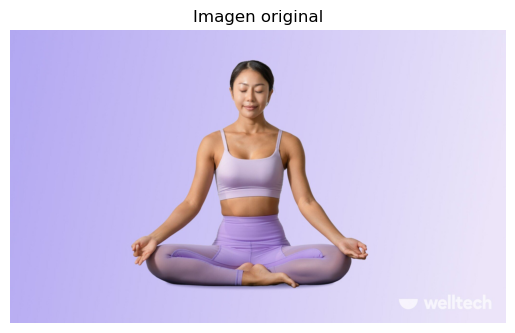

In [2]:
# Carga de imagen (Colab o local)
try:
    from google.colab import files
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]
except:
    img_path = "/home/jmsa/Imágenes/pose1.jpg"

img = cv2.imread(img_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis('off')
plt.show()

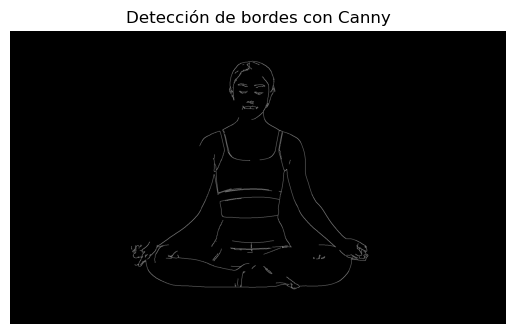

In [3]:
# Detección de bordes con Canny
edges = cv2.Canny(img_gray, 100, 200)
plt.imshow(edges, cmap='gray')
plt.title("Detección de bordes con Canny")
plt.axis('off')
plt.show()

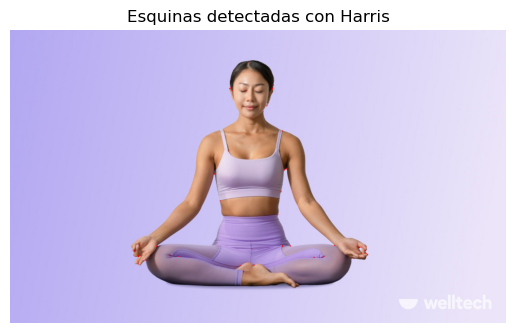

In [4]:
# Detección de esquinas con Harris
gray = np.float32(img_gray)
dst = cv2.cornerHarris(gray, 2, 3, 0.04)
dst = cv2.dilate(dst, None)
img_harris = img_rgb.copy()
img_harris[dst > 0.01 * dst.max()] = [255, 0, 0]  # marcar esquinas

plt.imshow(img_harris)
plt.title("Esquinas detectadas con Harris")
plt.axis('off')
plt.show()

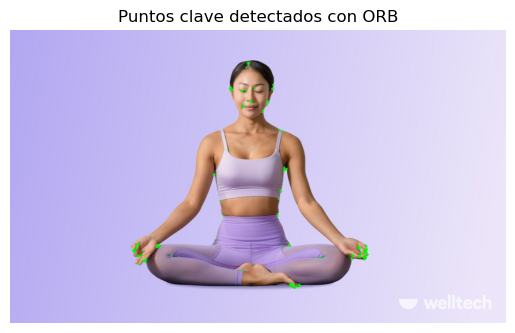

In [5]:
# Detección de puntos clave con ORB
orb = cv2.ORB_create()
keypoints, descriptors = orb.detectAndCompute(img_gray, None)
img_orb = cv2.drawKeypoints(img_rgb, keypoints, None, color=(0,255,0), flags=0)

plt.imshow(img_orb)
plt.title("Puntos clave detectados con ORB")
plt.axis('off')
plt.show()

In [6]:
# Actividad guiada
Markdown('''
**Actividad:**

1. Cambia los parámetros de Canny y Harris para observar diferencias.
2. Aplica ORB a una imagen diferente y compara el número de puntos detectados.
3. Reflexiona: ¿Qué tipo de características serían más útiles para un sistema de reconocimiento de objetos?
''')


**Actividad:**

1. Cambia los parámetros de Canny y Harris para observar diferencias.
2. Aplica ORB a una imagen diferente y compara el número de puntos detectados.
3. Reflexiona: ¿Qué tipo de características serían más útiles para un sistema de reconocimiento de objetos?
